In [3]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Saving model
import joblib

In [4]:
df = pd.read_csv(r"C:\Users\Muskaan R\Downloads\archive (2)\GlobalWeatherRepository.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124721 entries, 0 to 124720
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       124721 non-null  object 
 1   location_name                 124721 non-null  object 
 2   latitude                      124721 non-null  float64
 3   longitude                     124721 non-null  float64
 4   timezone                      124721 non-null  object 
 5   last_updated_epoch            124721 non-null  int64  
 6   last_updated                  124721 non-null  float64
 7   temperature_celsius           124721 non-null  float64
 8   temperature_fahrenheit        124721 non-null  float64
 9   condition_text                124721 non-null  object 
 10  wind_mph                      124721 non-null  float64
 11  wind_kph                      124721 non-null  float64
 12  wind_degree                   124721 non-nul

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,124721.000000,124721.000000,1.247210e+05,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,...,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000,124721.000000
mean,19.193490,21.992096,1.743601e+09,45749.658704,21.607207,70.894723,8.069774,12.990642,169.241948,1014.053503,...,18.313128,476.647246,58.932522,15.256413,10.680584,24.598199,49.231358,1.710057,2.633855,49.620938
std,24.425953,65.793159,1.600983e+07,185.297062,9.587039,17.256526,7.371973,11.860981,103.448265,10.616979,...,14.010257,782.702069,31.136430,24.282619,36.972602,37.853030,151.999242,0.950647,2.472296,35.042022
min,-41.300000,-175.200000,1.715849e+09,45428.070000,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.750000,-6.836100,1.729761e+09,45589.510000,16.300000,61.300000,3.800000,6.100000,80.000000,1010.000000,...,10.400000,210.900000,39.000000,1.650000,1.050000,7.100000,10.050000,1.000000,1.000000,15.000000
50%,17.250000,23.240000,1.743584e+09,45749.920000,24.100000,75.400000,6.900000,11.200000,162.000000,1014.000000,...,15.500000,303.400000,56.000000,5.450000,2.450000,14.245000,20.300000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.757492e+09,45910.090000,28.100000,82.600000,11.000000,17.600000,256.000000,1018.000000,...,24.300000,473.600000,75.000000,17.760000,8.650000,28.120000,42.180000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.771311e+09,46070.820000,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [5]:
columns_to_drop = [
    'temperature_fahrenheit',
    'feels_like_fahrenheit',
    'wind_mph',
    'gust_mph',
    'pressure_in',
    'precip_in',
    'location_name',
    'last_updated',
    'timezone'
]

df.drop(columns=columns_to_drop, inplace=True)

In [6]:
df.isnull().sum()
df.fillna(df.median(numeric_only=True), inplace=True)

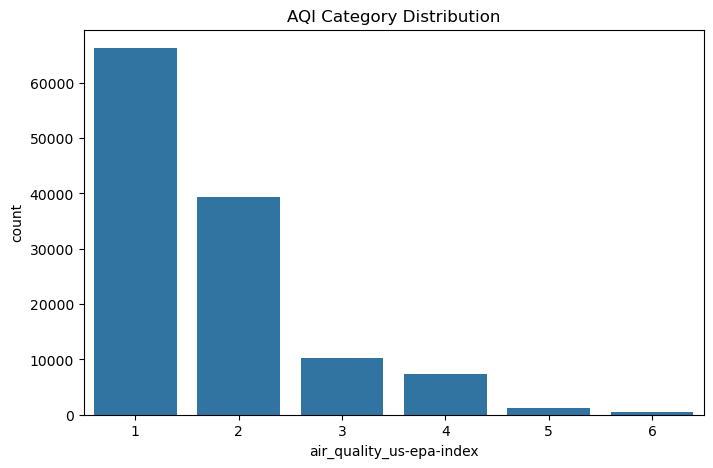

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='air_quality_us-epa-index', data=df)
plt.title("AQI Category Distribution")
plt.show()

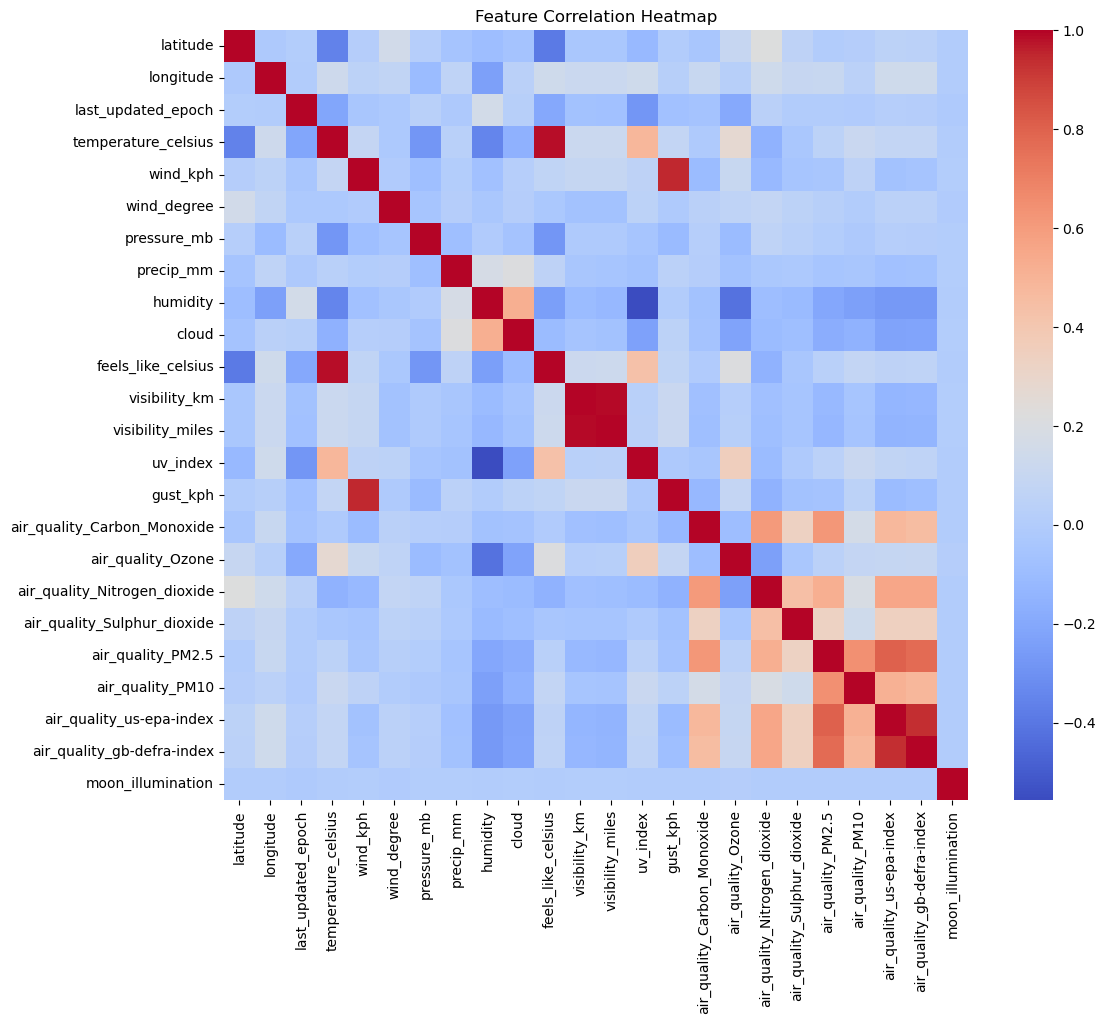

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

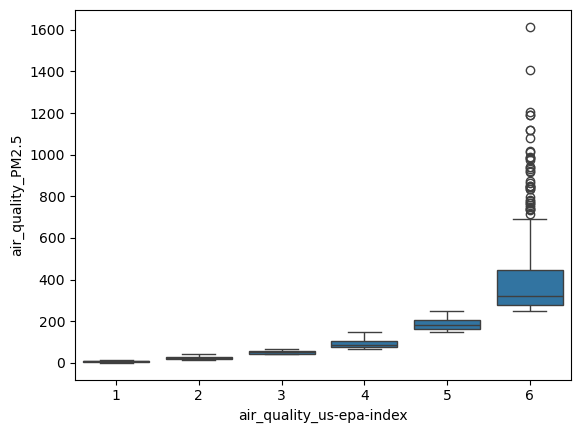

In [9]:
sns.boxplot(x='air_quality_us-epa-index',
            y='air_quality_PM2.5',
            data=df)
plt.show()

In [5]:
X = df.drop("air_quality_us-epa-index", axis=1)
y = df["air_quality_us-epa-index"]

In [41]:
# Keep only numeric columns

X_numeric = X.select_dtypes(include=['int64', 'float64'])

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

scores = cross_val_score(dt, X_numeric, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9999919823611947


In [10]:
categorical_cols = ['country', 'wind_direction', 'condition_text', 'moon_phase']

In [11]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize scaler
scaler = StandardScaler()

# Fit only on training numeric data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test numeric data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [18]:
X_train = X_train.select_dtypes(include=['int64', 'float64'])
X_test = X_test.select_dtypes(include=['int64', 'float64'])

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='macro'))
print("Recall:", recall_score(y_test, y_pred_lr, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.9870114251352976
Precision: 0.9865085441465008
Recall: 0.966158118956983
F1 Score: 0.9756186508214352

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     13254
           2       0.97      0.99      0.98      7860
           3       1.00      0.89      0.94      2046
           4       0.98      1.00      0.99      1468
           5       0.97      0.98      0.98       229
           6       1.00      0.93      0.96        88

    accuracy                           0.99     24945
   macro avg       0.99      0.97      0.98     24945
weighted avg       0.99      0.99      0.99     24945



In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [22]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='macro'))
print("Recall:", recall_score(y_test, y_pred_dt, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='macro'))

Decision Tree Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [24]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall:", recall_score(y_test, y_pred_rf, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='macro'))

Random Forest Results
Accuracy: 0.9997995590298657
Precision: 0.9970253138052901
Recall: 0.9923427826653635
F1 Score: 0.994583542481581


In [25]:
import pandas as pd

results = []

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, preds in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='macro'),
        "Recall": recall_score(y_test, preds, average='macro'),
        "F1 Score": f1_score(y_test, preds, average='macro')
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987011,0.986509,0.966158,0.975619
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.999800,0.997025,0.992343,0.994584


In [28]:
print("Target column exists:", "air_quality_us-epa-index" in df.columns)

Target column exists: True


In [29]:
from sklearn.model_selection import train_test_split

X = df.drop("air_quality_us-epa-index", axis=1)
y = df["air_quality_us-epa-index"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for classification
)

In [30]:
print(X_train.dtypes)

country                          object
latitude                        float64
longitude                       float64
last_updated_epoch                int64
temperature_celsius             float64
condition_text                   object
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                       int64
precip_mm                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
visibility_km                   float64
visibility_miles                  int64
uv_index                        float64
gust_kph                        float64
air_quality_Carbon_Monoxide     float64
air_quality_Ozone               float64
air_quality_Nitrogen_dioxide    float64
air_quality_Sulphur_dioxide     float64
air_quality_PM2.5               float64
air_quality_PM10                float64
air_quality_gb-defra-index        int64


In [31]:
X_train = X_train.select_dtypes(include=['int64', 'float64'])
X_test = X_test.select_dtypes(include=['int64', 'float64'])

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9874123070755663


In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9938665063138905


In [36]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.987412
1        Decision Tree  1.000000
2        Random Forest  0.993867


In [37]:
print(df.shape)

(124721, 32)


In [38]:
print("Train Accuracy:", dt.score(X_train, y_train))
print("Test Accuracy:", dt.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


In [43]:
X = df.drop("air_quality_us-epa-index", axis=1)
y = df["air_quality_us-epa-index"]

In [44]:
# Keep only numeric columns

X_numeric = X.select_dtypes(include=['int64', 'float64'])
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

scores = cross_val_score(dt, X_numeric, y, cv=5)

print("Cross-validation accuracy:", scores.mean())


Cross-validation accuracy: 0.9999919823611947


In [45]:
print(df.columns)

Index(['country', 'latitude', 'longitude', 'last_updated_epoch',
       'temperature_celsius', 'condition_text', 'wind_kph', 'wind_degree',
       'wind_direction', 'pressure_mb', 'precip_mm', 'humidity', 'cloud',
       'feels_like_celsius', 'visibility_km', 'visibility_miles', 'uv_index',
       'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')


In [10]:
import pandas as pd

df['last_updated'] = pd.to_datetime(df['last_updated_epoch'], unit='s')

In [11]:
df = df.sort_values(['country', 'last_updated'])

In [12]:
df['AQI_next_step'] = df.groupby('country')['air_quality_us-epa-index'].shift(-1)

In [13]:
X = df.drop([
    'air_quality_us-epa-index',
    'AQI_next_step',
    'last_updated',
    'last_updated_epoch'
], axis=1)

y = df['AQI_next_step']

In [14]:
X = X.select_dtypes(include=['int64', 'float64'])

In [15]:
df = df.sort_values(['country', 'last_updated'])

df['AQI_next_step'] = df.groupby('country')['air_quality_us-epa-index'].shift(-1)

In [16]:
df = df.dropna(subset=['AQI_next_step'])

In [17]:
def merge_aqi(x):
    if x <= 2:
        return 0
    elif x <= 4:
        return 1
    else:
        return 2

df['AQI_next_step'] = df['AQI_next_step'].apply(merge_aqi)

In [18]:
X = df.drop([
    'air_quality_us-epa-index',
    'AQI_next_step',
    'last_updated',
    'last_updated_epoch'
], axis=1)

y = df['AQI_next_step']

In [19]:
X = X.select_dtypes(include=['int64', 'float64'])

In [20]:
print("NaN in y:", y.isna().sum())
print("NaN in X:", X.isna().sum().sum())

NaN in y: 0
NaN in X: 0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
#new 
import pandas as pd

df = pd.read_csv(r"C:\Users\Muskaan R\Downloads\archive (2)\GlobalWeatherRepository.csv")

In [23]:
df['last_updated'] = pd.to_datetime(df['last_updated_epoch'], unit='s')
df = df.sort_values(['country', 'last_updated'])

df['AQI_next_step'] = df.groupby('country')['air_quality_us-epa-index'].shift(-1)

In [18]:
df = df.dropna(subset=['AQI_next_step'])
print("NaN in AQI_next_step:", df['AQI_next_step'].isna().sum())

NaN in AQI_next_step: 0


In [24]:
def merge_aqi(x):
    if x <= 2:
        return 0
    elif x <= 4:
        return 1
    else:
        return 2

df['AQI_next_step'] = df['AQI_next_step'].apply(merge_aqi)

In [25]:
print("NaN in AQI_next_step after merge:", df['AQI_next_step'].isna().sum())

NaN in AQI_next_step after merge: 0


In [26]:
X = df.drop([
    'AQI_next_step',
    'air_quality_us-epa-index',
    'last_updated',
    'last_updated_epoch'
], axis=1)

X = X.select_dtypes(include=['int64', 'float64'])

y = df['AQI_next_step']

In [27]:
print("NaN in X:", X.isna().sum().sum())
print("NaN in y:", y.isna().sum())

NaN in X: 0
NaN in y: 0


In [28]:
split_index = int(0.8 * len(df))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (99776, 28)
Test shape: (24945, 28)


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.8689516937261976


In [30]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.8870314692323111


C:\Users\Muskaan R\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.884786530366807


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42,
    n_jobs=-1   # uses all CPU cores
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8865103227099619


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.8630587292042493


In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.8711966325917018


In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.889356584485869


In [36]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_gb,
        acc_knn,
        acc_xgb
    ]
})

print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
5              XGBoost  0.889357
0  Logistic Regression  0.887031
2        Random Forest  0.886510
1        Decision Tree  0.884787
4                  KNN  0.871197
3    Gradient Boosting  0.863059


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     21279
           1       0.64      0.53      0.58      3504
           2       0.21      0.04      0.06       162

    accuracy                           0.89     24945
   macro avg       0.59      0.51      0.53     24945
weighted avg       0.88      0.89      0.88     24945



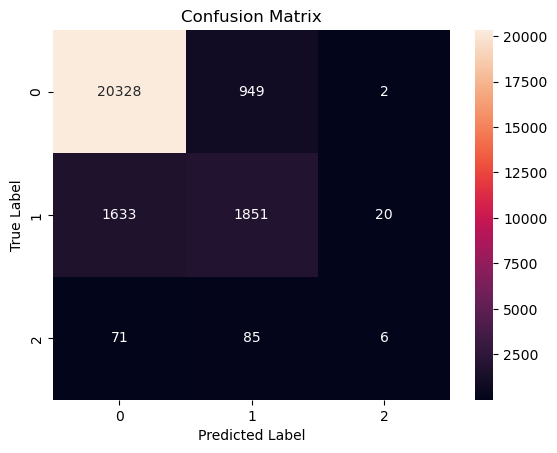

In [39]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Use your best model
best_model = xgb   # or grid_xgb.best_estimator_ if tuned

y_pred = best_model.predict(X_test)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [40]:
import pandas as pd

importances = best_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

                        Feature  Importance
24            air_quality_PM2.5    0.543757
26   air_quality_gb-defra-index    0.138215
1                     longitude    0.046916
0                      latitude    0.027433
25             air_quality_PM10    0.018029
12                        cloud    0.016967
20  air_quality_Carbon_Monoxide    0.015623
3        temperature_fahrenheit    0.014659
14        feels_like_fahrenheit    0.013251
17                     uv_index    0.013129


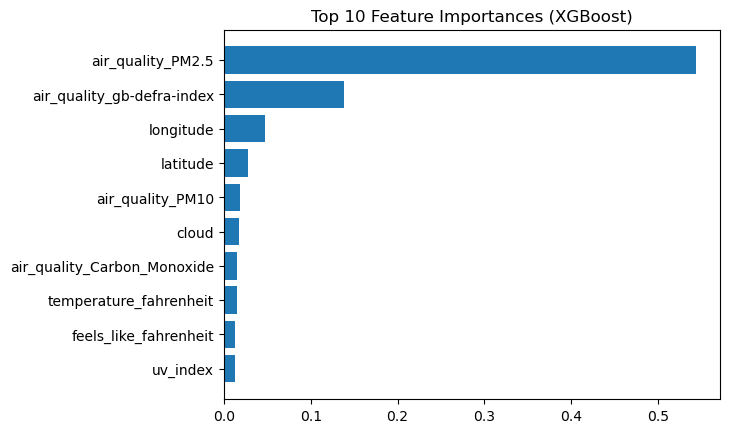

In [41]:
plt.figure()
plt.barh(feature_importance_df["Feature"][:10], feature_importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

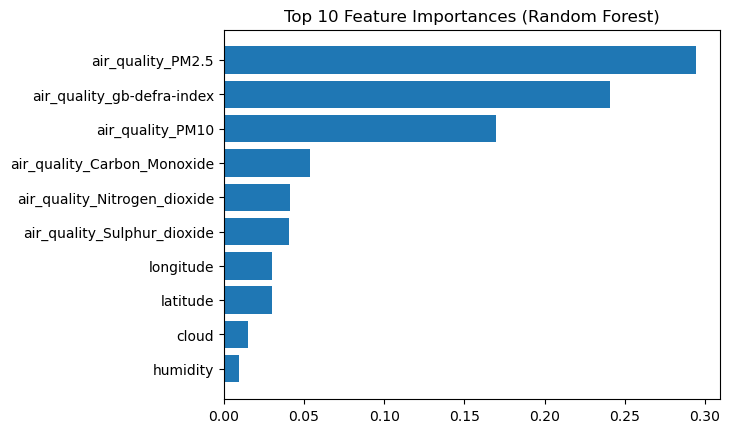

In [42]:
rf_importances = rf.feature_importances_

rf_feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(rf_feature_df["Feature"][:10], rf_feature_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

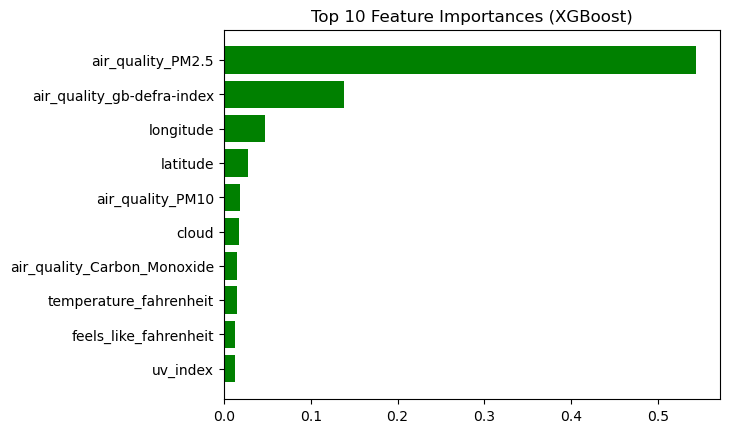

In [43]:
import pandas as pd

importances = best_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(
    feature_importance_df["Feature"][:10],
    feature_importance_df["Importance"][:10],
    color='green'   # changed color
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

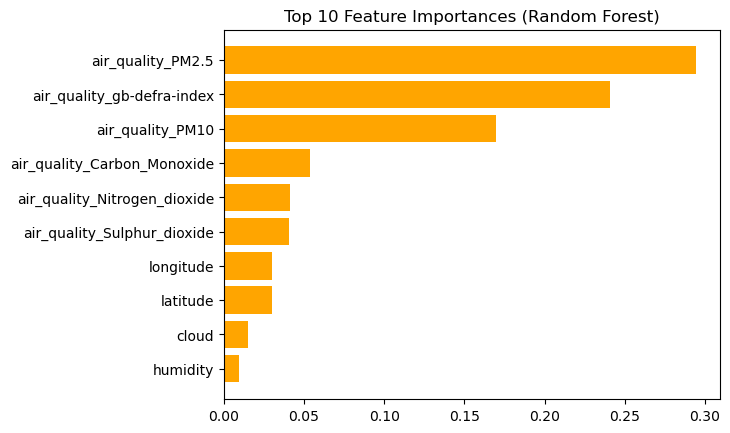

In [44]:
rf_importances = rf.feature_importances_

rf_feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(
    rf_feature_df["Feature"][:10],
    rf_feature_df["Importance"][:10],
    color='orange'   # different color
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

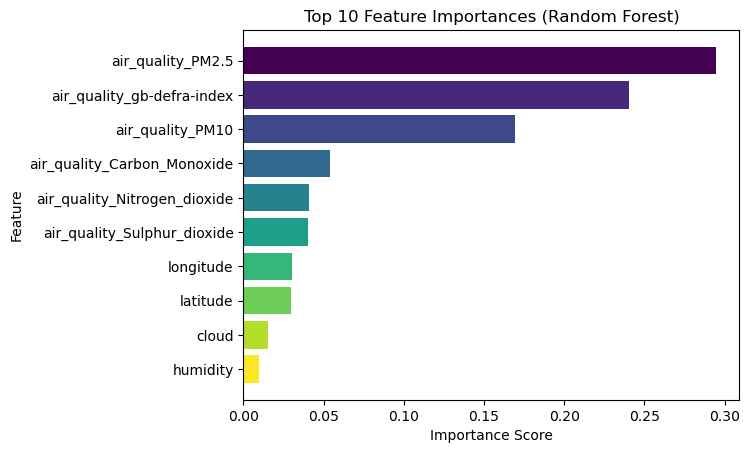

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

# Create dataframe
rf_importances = rf.feature_importances_

rf_feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

# Take top 10
top_features = rf_feature_df.head(10)

# Create gradient colors
colors = cm.viridis(np.linspace(0, 1, len(top_features)))

plt.figure()
plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=colors
)

plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

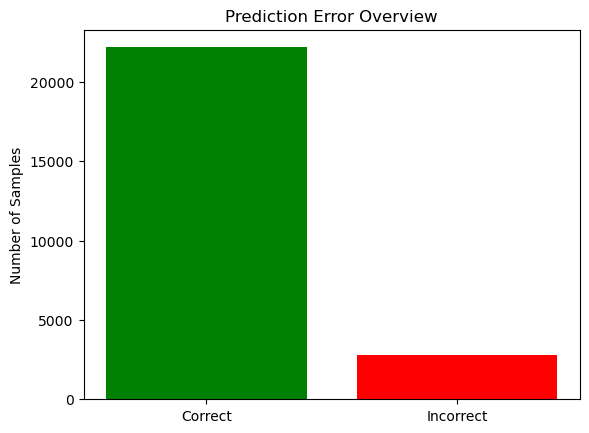

Accuracy: 0.889356584485869


In [46]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

correct = np.sum(y_pred == y_test)
incorrect = np.sum(y_pred != y_test)

plt.figure()
plt.bar(["Correct", "Incorrect"], [correct, incorrect], color=["green", "red"])
plt.title("Prediction Error Overview")
plt.ylabel("Number of Samples")
plt.show()

print("Accuracy:", correct / (correct + incorrect))

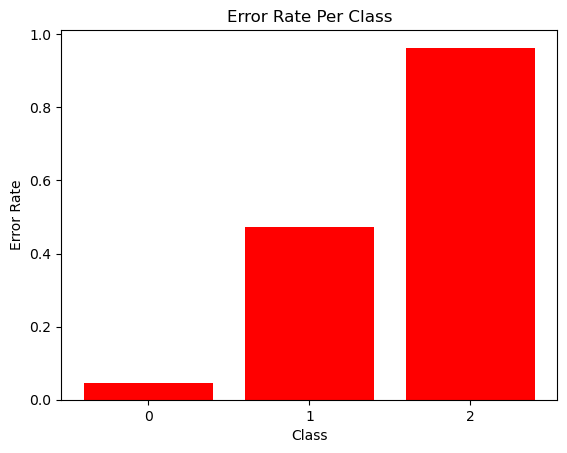

Actual
0    0.044692
1    0.471747
2    0.962963
Name: Error, dtype: float64


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

errors = y_pred != y_test

error_df = pd.DataFrame({
    "Actual": y_test,
    "Error": errors
})

error_rate = error_df.groupby("Actual")["Error"].mean()

plt.figure()
plt.bar(error_rate.index.astype(str), error_rate.values, color="red")
plt.title("Error Rate Per Class")
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.show()

print(error_rate)

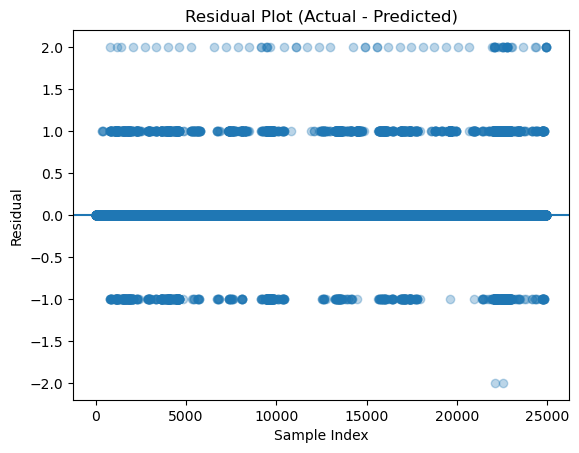

In [48]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(range(len(residuals)), residuals, alpha=0.3)
plt.axhline(0)
plt.title("Residual Plot (Actual - Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("Residual")
plt.show()

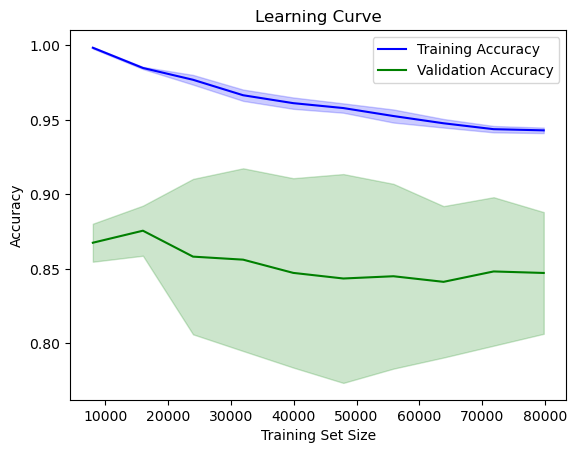

In [49]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Use your final model
model = best_model   # or xgb / rf / lr

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure()

plt.plot(train_sizes, train_mean, label="Training Accuracy", color="blue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")

plt.plot(train_sizes, val_mean, label="Validation Accuracy", color="green")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="green")

plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [50]:
final_model = xgb   # or logistic if you prefer lightweight

In [52]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [53]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [54]:
import joblib
joblib.dump(final_model, "aqi_model.pkl")

['aqi_model.pkl']

In [55]:
print(X.columns)

Index(['latitude', 'longitude', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_gb-defra-index',
       'moon_illumination'],
      dtype='object')


In [56]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [58]:
import joblib

joblib.dump(best_model, "aqi_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [59]:
import os
os.getcwd()

'C:\\Users\\Muskaan R'